# 📊 Bloque 1 — Sesión 1: Población, muestra y medidas de centralidad

**Módulo:** Depuración, Limpieza y Clasificación de Datos (5109)  
**Unidad Didáctica:** UD2 — Verificación estadística de la calidad de los datos  
**Duración estimada:** ~4 horas

---

### Contenidos de esta sesión
- **1.1** Población y muestra: conceptos, diferencias y relación con el ML
- **1.2** Medidas de centralidad: media, mediana y moda

### Criterios de evaluación asociados
> **(CE a)** Se han descrito las técnicas estadísticas de análisis de la calidad técnica de los datos, que se aplican para su verificación, explicando sus características y objetivos.  
> **(CE b)** Se han aplicado técnicas de evaluación de la calidad de los datos basadas en cálculos estadísticos tales como frecuencia y distribución, para detectar la cobertura y el sesgo, describiendo sus características.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

print('✅ Librerías cargadas correctamente')

✅ Librerías cargadas correctamente


---
## 1.1 Población y muestra

### ¿Qué es la población?

En estadística, la **población** es el conjunto completo de individuos, objetos o medidas sobre los que queremos obtener información. Por ejemplo, "todos los correos electrónicos enviados en el mundo en 2024" o "todas las transacciones bancarias fraudulentas posibles".

En la práctica, **nunca tenemos acceso a la población completa**. Lo que tenemos es una **muestra**: un subconjunto de la población que usamos para extraer conclusiones.

| Concepto | Símbolo habitual | Descripción |
|----------|-----------------|-------------|
| **Población** | N | Todos los casos posibles del fenómeno |
| **Muestra** | n | Subconjunto representativo que observamos |
| **Parámetro** | μ, σ | Estadístico *real* de la población (desconocido) |
| **Estimador** | x̄, s | Aproximación del parámetro calculada desde la muestra |

> 💡 **Clave para ML:** el dataset de entrenamiento es siempre una muestra. Los modelos que entrenamos aprenden patrones de esa muestra e intentan generalizarlos a la población. Si la muestra no es representativa (está sesgada), el modelo tampoco lo será.

### 📌 Ejemplo 1 — Población vs. muestra en un dataset real

Usaremos el dataset **Titanic** como metáfora: los 891 pasajeros de nuestro CSV son la *muestra*; la *población* sería el comportamiento de supervivencia de cualquier persona ante un naufragio similar.

In [3]:
# Cargamos el dataset Titanic desde seaborn (no requiere fichero local)
titanic = sns.load_dataset('titanic')

print(f'Tamaño de la muestra (n): {len(titanic)} filas')
print(f'Variables disponibles: {titanic.shape[1]}')
print()
print(titanic.head())

Tamaño de la muestra (n): 891 filas
Variables disponibles: 15

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  


### Representatividad de la muestra

Que una muestra sea grande no significa que sea representativa. Lo importante es cómo se seleccionó. En ML, los problemas más comunes son:

- **Sesgo de selección**: los datos no cubren todos los grupos de la población. Por ejemplo, entrenar un modelo de detección de fraude solo con datos de un país.
- **Sesgo temporal**: los datos históricos no reflejan el comportamiento actual (concept drift).
- **Desbalanceo de clases**: una categoría está sobrerrepresentada respecto a las demás.

In [4]:
# Comprobemos si la muestra del Titanic está balanceada por clase social
print("Distribución por clase (pclass):")
print(titanic['pclass'].value_counts(normalize=True).mul(100).round(1).astype(str) + ' %')
print()
print("Distribución por sexo:")
print(titanic['sex'].value_counts(normalize=True).mul(100).round(1).astype(str) + ' %')
print()
print("Distribución por supervivencia (variable objetivo):")
print(titanic['survived'].value_counts(normalize=True).mul(100).round(1).astype(str) + ' %')

Distribución por clase (pclass):
pclass
3    55.1 %
1    24.2 %
2    20.7 %
Name: proportion, dtype: object

Distribución por sexo:
sex
male      64.8 %
female    35.2 %
Name: proportion, dtype: object

Distribución por supervivencia (variable objetivo):
survived
0    61.6 %
1    38.4 %
Name: proportion, dtype: object


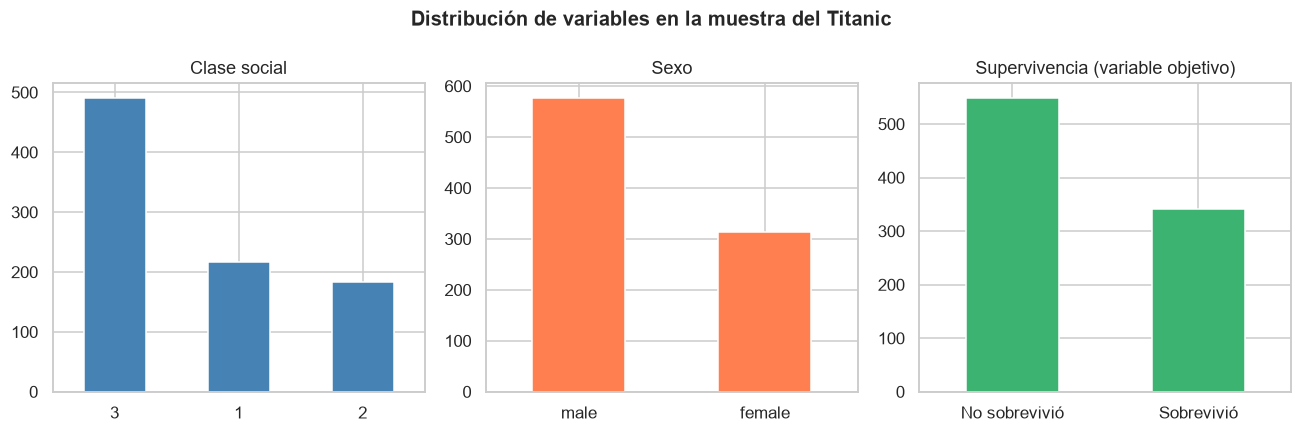

In [5]:
# Visualización del desbalanceo
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

titanic['pclass'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Clase social')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=0)

titanic['sex'].value_counts().plot(kind='bar', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Sexo')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0)

titanic['survived'].map({0:'No sobrevivió', 1:'Sobrevivió'}).value_counts().plot(
    kind='bar', ax=axes[2], color='mediumseagreen', edgecolor='white')
axes[2].set_title('Supervivencia (variable objetivo)')
axes[2].set_xlabel('')
axes[2].tick_params(axis='x', rotation=0)

plt.suptitle('Distribución de variables en la muestra del Titanic', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 1.2 Medidas de centralidad

Las medidas de centralidad describen el **valor típico o central** de una distribución. Son los estadísticos más básicos, pero su interpretación correcta es fundamental para evaluar la calidad de los datos.

### Media aritmética (x̄)

La media es la suma de todos los valores dividida entre el número de observaciones:

$$\bar{x} = \frac{1}{n} \sum_{i=1}^{n} x_i$$

**Ventaja:** fácil de calcular e interpretar.  
**Limitación:** muy sensible a valores extremos (*outliers*). Un solo valor atípico puede desplazar la media de forma engañosa.

In [6]:
# Comparación de media con y sin outlier
salarios_normales = [25000, 27000, 28000, 26000, 30000, 24000, 29000]
salarios_con_ceo = salarios_normales + [1_200_000]  # director general

media_normal = np.mean(salarios_normales)
media_ceo = np.mean(salarios_con_ceo)

print(f"Salarios normales: {salarios_normales}")
print(f"Media sin CEO: {media_normal:,.0f} €")
print()
print(f"Salarios con CEO: {salarios_con_ceo}")
print(f"Media con CEO:    {media_ceo:,.0f} €")
print()
print("→ La media sube de ~27.000 € a ~170.000 € por un solo valor atípico.")
print("  Nadie de la plantilla gana cerca de 170.000 €. La media es engañosa.")

Salarios normales: [25000, 27000, 28000, 26000, 30000, 24000, 29000]
Media sin CEO: 27,000 €

Salarios con CEO: [25000, 27000, 28000, 26000, 30000, 24000, 29000, 1200000]
Media con CEO:    173,625 €

→ La media sube de ~27.000 € a ~170.000 € por un solo valor atípico.
  Nadie de la plantilla gana cerca de 170.000 €. La media es engañosa.


### Mediana

La mediana es el **valor central** cuando los datos están ordenados. Divide la distribución en dos mitades iguales.

- Si n es impar: es el valor del elemento central.  
- Si n es par: es la media de los dos elementos centrales.

**Ventaja:** robusta ante outliers.  
**Cuándo usarla:** siempre que la distribución sea asimétrica (salarios, precios de vivienda, tiempos de respuesta).

In [7]:
# La mediana no se ve afectada por el CEO
mediana_normal = np.median(salarios_normales)
mediana_ceo = np.median(salarios_con_ceo)

print(f"Mediana sin CEO: {mediana_normal:,.0f} €")
print(f"Mediana con CEO: {mediana_ceo:,.0f} €")
print()
print("→ La mediana apenas cambia: es un estimador robusto del valor central.")

Mediana sin CEO: 27,000 €
Mediana con CEO: 27,500 €

→ La mediana apenas cambia: es un estimador robusto del valor central.


### Moda

La moda es el **valor que aparece con más frecuencia**. Se usa principalmente con variables categóricas o discretas.

- Una distribución puede ser **unimodal** (una moda), **bimodal** (dos modas) o **multimodal**.
- En variables numéricas continuas, es poco útil salvo que los datos estén discretizados.

In [8]:
# Moda en variables categóricas y numéricas
print("Moda de la clase de cabina (Titanic):")
print(titanic['pclass'].mode().values)

print()
print("Moda del sexo:")
print(titanic['sex'].mode().values)

print()
print("Moda de la edad (numérica continua → poco informativa):")
print(titanic['age'].mode().values, "← coincidencia de redondeo, no patrón real")

Moda de la clase de cabina (Titanic):
[3]

Moda del sexo:
['male']

Moda de la edad (numérica continua → poco informativa):
[24.] ← coincidencia de redondeo, no patrón real


### 📌 Ejemplo 2 — Comparación de las tres medidas sobre la edad del Titanic

Media:   29.70 años
Mediana: 28.0 años
Moda:    24.0 años


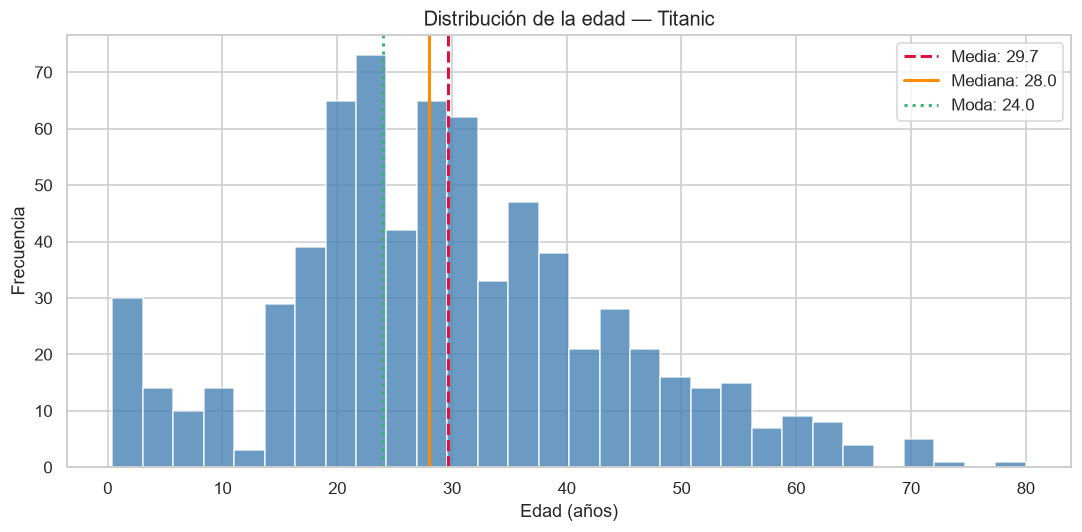


→ La distribución tiene un ligero sesgo a la derecha (cola larga hacia edades altas).
  Por eso media > mediana. En distribuciones simétricas, las tres coinciden.


In [9]:
edad = titanic['age'].dropna()

media_edad = edad.mean()
mediana_edad = edad.median()
moda_edad = edad.mode()[0]

print(f"Media:   {media_edad:.2f} años")
print(f"Mediana: {mediana_edad:.1f} años")
print(f"Moda:    {moda_edad:.1f} años")

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(edad, bins=30, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(media_edad, color='crimson', linewidth=2, linestyle='--', label=f'Media: {media_edad:.1f}')
ax.axvline(mediana_edad, color='darkorange', linewidth=2, linestyle='-', label=f'Mediana: {mediana_edad:.1f}')
ax.axvline(moda_edad, color='mediumseagreen', linewidth=2, linestyle=':', label=f'Moda: {moda_edad:.1f}')
ax.set_xlabel('Edad (años)')
ax.set_ylabel('Frecuencia')
ax.set_title('Distribución de la edad — Titanic', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

print()
print("→ La distribución tiene un ligero sesgo a la derecha (cola larga hacia edades altas).")
print("  Por eso media > mediana. En distribuciones simétricas, las tres coinciden.")

### ¿Cuándo usar cada medida?

| Medida | Tipo de variable | Situación ideal |
|--------|-----------------|-----------------|
| **Media** | Numérica | Distribución simétrica sin outliers significativos |
| **Mediana** | Numérica | Distribución asimétrica o con outliers (salarios, precios) |
| **Moda** | Categórica o discreta | Variables nominales, ordinales o para detectar valores dominantes |

> 💡 **Regla práctica:** compara siempre media y mediana. Si difieren mucho, hay asimetría u outliers. Eso es información sobre la calidad del dato.

### 📌 Ejemplo 3 — Función resumen de centralidad

In [10]:
def resumen_centralidad(df, columnas_num):
    """Calcula y compara media, mediana y moda para un conjunto de columnas numéricas."""
    resultados = []
    for col in columnas_num:
        serie = df[col].dropna()
        media = serie.mean()
        mediana = serie.median()
        moda = serie.mode().iloc[0] if not serie.mode().empty else None
        diferencia_pct = abs(media - mediana) / mediana * 100 if mediana != 0 else np.nan
        alerta = '⚠️ asimetría/outliers' if diferencia_pct > 10 else '✅ distribución simétrica'
        resultados.append({
            'Variable': col,
            'Media': round(media, 2),
            'Mediana': round(mediana, 2),
            'Moda': round(moda, 2) if moda is not None else None,
            '|Media-Mediana|/Mediana %': round(diferencia_pct, 1),
            'Diagnóstico': alerta
        })
    return pd.DataFrame(resultados).set_index('Variable')

cols_num = ['age', 'fare', 'sibsp', 'parch']
resumen_centralidad(titanic, cols_num)

,Media,Mediana,Moda,|Media-Mediana|/Mediana %,Diagnóstico
Variable,,,,,
age,29.70,28.00,24.00,6.1,✅ distribución simétrica
fare,32.20,14.45,8.05,122.8,⚠️ asimetría/outliers
sibsp,0.52,0.00,0.00,NaN,✅ distribución simétrica
parch,0.38,0.00,0.00,NaN,✅ distribución simétrica


---
## 🔧 Ejercicios

### Ejercicio 1 — Representatividad de la muestra

El dataset `diamonds` de seaborn contiene precios y características de 53.940 diamantes. Analiza si la muestra está balanceada respecto a la variable `cut` (calidad del corte). ¿Qué implicaciones tendría entrenar un modelo de predicción de precio con esta distribución?

In [11]:
diamonds = sns.load_dataset('diamonds')

# 1. Muestra la distribución de la variable 'cut'
# print(diamonds['cut'].value_counts(normalize=True))

# 2. Visualiza la distribución con un gráfico de barras
# ...

# 3. Escribe tu conclusión como comentario
# ¿Es representativa la muestra para todos los tipos de corte?

### Ejercicio 2 — Media vs. mediana en precios

Usando el mismo dataset `diamonds`, calcula la media y mediana del precio (`price`). ¿Cuál es más representativa del precio "típico" de un diamante? Justifica tu respuesta con un histograma.

In [12]:
# 1. Calcula media y mediana del precio
# media_precio = ...
# mediana_precio = ...

# 2. Traza el histograma con líneas verticales para cada estadístico
# fig, ax = plt.subplots(figsize=(10, 5))
# ...

# 3. ¿Qué medida usarías para describir el precio típico? ¿Por qué?

### Ejercicio 3 — Función resumen_centralidad

Aplica la función `resumen_centralidad()` definida en el Ejemplo 3 al dataset `diamonds` para las columnas numéricas `price`, `carat`, `depth` y `table`. Interpreta las alertas: ¿qué variables presentan asimetría?

In [13]:
# Aplica resumen_centralidad al dataset diamonds
# cols = ['price', 'carat', 'depth', 'table']
# resumen_centralidad(diamonds, cols)

# Comenta los resultados: ¿qué variables tienen asimetría pronunciada?
# ¿Cómo podría afectar eso al entrenamiento de un modelo?

---
## 📝 Resumen de la sesión

| Concepto | Clave |
|----------|-------|
| **Población** | Conjunto completo del fenómeno. En ML, nunca observable en su totalidad. |
| **Muestra** | Subconjunto que usamos para entrenar. Su representatividad determina la del modelo. |
| **Parámetro vs. estimador** | Los parámetros reales (μ, σ) son desconocidos; los estimadores (x̄, s) los aproximan. |
| **Media** | Sensible a outliers. Representativa solo en distribuciones simétricas. |
| **Mediana** | Robusta ante outliers. Preferible con distribuciones asimétricas. |
| **Moda** | Para variables categóricas o para detectar el valor más frecuente. |
| **Diagnóstico rápido** | Si \|media − mediana\| / mediana > 10 %, hay asimetría u outliers relevantes. |

### 🔜 Próxima sesión
**Bloque 1 — Sesión 2:** Medidas de dispersión (varianza, desviación típica, IQR, percentiles), interpretación en ML y visualización con histogramas y boxplots.